# Phase 3: Transfer & Universality of VoG-Based Data Ranking

**Project:** Impact of Data Ranking on Training Dynamics  
**Dataset:** Imagenette (`frgfm/imagenette`)  
**Phase 3 model:** `torchvision.models.convnext_base` (ConvNeXt_Base_Weights.IMAGENET1K_V1)  
**Reference model:** `torchvision.models.resnet50` (ResNet50_Weights.IMAGENET1K_V2)  
**Method:** Variance of Gradients (VoG)  
**Paper:** Agarwal et al., *"Estimating Example Difficulty Using Variance of Gradients"* (CVPR 2022)  
**Original code:** https://github.com/chirag-agarwall/VOG

---

## Objectives

1. **Compute VoG scores independently** for both ResNet50 and ConvNeXt-Base using the original algorithm
2. **Cross-architecture consistency:** do both models agree on which samples are hard?
3. **Train ConvNeXt-Base** on subsets ranked by:
   - ResNet50's VoG (cross-architecture transfer)
   - ConvNeXt's own VoG (self-ranked)
4. **Compare efficiency** in both Frozen (Linear Probe) and Unfrozen (Fine-tuning) modes

## Central Hypothesis

> If VoG captures **intrinsic data difficulty** rather than architecture-specific features, then:
> - Rankings from ResNet50 and ConvNeXt should correlate strongly (Spearman ρ > 0.5)
> - Cross-architecture VoG transfer should perform within 2% of self-ranked VoG

## Architecture Comparison

| Model | Architecture | Weights | Params | Design |
|-------|-------------|---------|--------|--------|
| ResNet50 | Residual CNN | IMAGENET1K_V2 | ~25M | 2015 |
| ConvNeXt-Base | Modern CNN (transformer-inspired) | IMAGENET1K_V1 | ~89M | 2022 |


In [1]:
# Kaggle: torch, torchvision, matplotlib, numpy, seaborn, scipy, tqdm are pre-installed.
# This cell installs any that are missing (no-op on Kaggle, useful for other envs).
import importlib, subprocess, sys
required = ['torch', 'torchvision', 'tqdm', 'matplotlib', 'numpy', 'seaborn', 'scipy']
missing  = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
if missing:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + missing, check=False)
    print(f'Installed: {missing}')
else:
    print('All dependencies present (Kaggle / pre-installed environment).')

All dependencies present (Kaggle / pre-installed environment).


In [2]:
import os
import gc
# Set before any CUDA allocation — reduces fragmentation OOM on large models like ConvNeXt
os.environ.setdefault('PYTORCH_ALLOC_CONF', 'expandable_segments:True')

import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
import torchvision.transforms as transforms
from torchvision.models import (
    resnet50, ResNet50_Weights,
    convnext_base, ConvNeXt_Base_Weights,
)
from torchvision.datasets import Imagenette

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
sns.set_style('whitegrid')

# ── GPU / hardware setup ────────────────────────────────────────────────────
n_gpus = torch.cuda.device_count()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    for i in range(n_gpus):
        props = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}: {props.name}  ({props.total_memory / 1e9:.1f} GB)')
    print(f'  → Training on single GPU (DataParallel disabled — see note below)')

USE_AMP = device.type == 'cuda'   # T4 supports FP16 Tensor Cores

# ── Hyperparameters ─────────────────────────────────────────────────────────
SEED             = 42
# ConvNeXt-Base (27 Stage-3 blocks) stores ~12 GB of FP32 activations at batch=64.
# Batch=32 + AMP in VoG passes reduces peak to ~3-4 GB — comfortably within 16 GB T4.
VOG_BATCH_SIZE   = 32    # single GPU; AMP in VoG passes halves activation memory further
# DataParallel is NOT used — see train_and_evaluate for why.
# At batch=128 on a single T4 (16 GB), ConvNeXt-Base full fine-tuning stores ~12 GB
# of FP16 activations → OOM.  batch=64 keeps peak at ~6 GB — safe on T4.
TRAIN_BATCH_SIZE = 64
NUM_WORKERS      = 2
VOG_EPOCHS       = 5
TRAIN_EPOCHS     = 10
NUM_CLASSES      = 10
SUBSET_FRACTION  = 0.3
VOG_POOL_SIZE    = 32

DATA_DIR  = '/kaggle/working/data'
CACHE_DIR = '/kaggle/working'

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

IMAGENETTE_CLASSES = [
    'tench', 'English springer', 'cassette player', 'chain saw',
    'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute'
]
COLORS = {
    'Full':          '#2196F3',
    'High_VoG_R50':  '#F44336',
    'Low_VoG_R50':   '#4CAF50',
    'High_VoG_CNX':  '#FF5722',
    'Low_VoG_CNX':   '#009688',
    'resnet':        '#FF6B35',
    'convnext':      '#7C4DFF',
}
print(f'\nAMP={USE_AMP}  |  GPUs={n_gpus}  |  '
      f'VoG batch={VOG_BATCH_SIZE}  |  Train batch={TRAIN_BATCH_SIZE}')
print('Setup complete.')

Device : cuda
  GPU 0: Tesla T4  (15.6 GB)
  GPU 1: Tesla T4  (15.6 GB)
  → Training on single GPU (DataParallel disabled — see note below)

AMP=True  |  GPUs=2  |  VoG batch=32  |  Train batch=64
Setup complete.


In [3]:
class TensorCacheDataset(Dataset):
    """Store images as uint8 (3×224×224) in CPU RAM; collate converts to float32.

    Memory
    ------
    float32 cache (old): N × 3 × 224 × 224 × 4 B  →  train ≈5.7 GB, val ≈2.4 GB
    uint8  cache (new):  N × 3 × 224 × 224 × 1 B  →  train ≈1.4 GB, val ≈0.6 GB

    __getitem__ returns the raw uint8 slice — zero new allocation (it is a view
    into self.data that shares the same storage).  The custom collate function
    `normalize_collate` stacks the batch as uint8 first (1 × 19 MB allocation),
    then converts the whole batch to float32 (1 × 77 MB allocation) and normalizes
    in-place — 2 allocs/batch instead of 128+1.  With num_workers=0 this keeps
    GPU >85% busy (collate ≈15-20 ms << GPU ≈150 ms).
    """

    def __init__(self, base_dataset, cache_path=None, desc='dataset'):
        _spatial = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])

        if cache_path and os.path.exists(cache_path):
            saved = torch.load(cache_path, map_location='cpu')
            if saved['data'].dtype == torch.uint8:
                print(f'Loading {desc} uint8 cache from disk...', flush=True)
                self.data   = saved['data']    # (N, 3, 224, 224) uint8
                self.labels = saved['labels']  # (N,) int64
            else:
                # Old float32 cache — delete and rebuild as uint8
                print(f'Old float32 cache detected — rebuilding as uint8...', flush=True)
                os.remove(cache_path)
                self._build(base_dataset, _spatial, cache_path, desc)
        else:
            self._build(base_dataset, _spatial, cache_path, desc)

        gb = self.data.numel() / 1e9          # 1 byte per element for uint8
        print(f'  {desc}: {len(self):,} images | {gb:.2f} GB in RAM (uint8)', flush=True)

    def _build(self, base_dataset, spatial_tf, cache_path, desc):
        print(f'Building {desc} uint8 cache ({len(base_dataset)} images) — '
              f'one-time cost ~2 min...', flush=True)
        imgs, lbls = [], []
        for i in tqdm(range(len(base_dataset)), desc=f'  {desc}', leave=True):
            img_pil, lbl = base_dataset[i]
            if img_pil.mode != 'RGB':
                img_pil = img_pil.convert('RGB')
            img_pil = spatial_tf(img_pil)                               # PIL 224×224
            img_u8  = torch.from_numpy(np.array(img_pil, dtype=np.uint8)) # (224,224,3)
            imgs.append(img_u8.permute(2, 0, 1).contiguous())             # (3,224,224)
            lbls.append(lbl)
        self.data   = torch.stack(imgs)                                    # (N,3,224,224) uint8
        self.labels = torch.tensor(lbls, dtype=torch.long)
        if cache_path:
            print(f'  Saving uint8 cache to {cache_path}...', flush=True)
            torch.save({'data': self.data, 'labels': self.labels}, cache_path)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Returns a uint8 VIEW into self.data — zero allocation.
        # normalize_collate handles float32 conversion for the whole batch at once.
        return self.data[idx], self.labels[idx].item(), idx


# Normalization constants (on CPU; normalize_collate keeps them here)
_COLLATE_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
_COLLATE_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def normalize_collate(batch):
    """Custom collate: batch-level uint8→float32 conversion.

    Default collate calls __getitem__ 128× → 128 individual 0.6 MB float32
    tensors + 1 stack = 129 allocs/batch.  This collate stacks uint8 first
    (views into self.data, so the stack is the only real alloc, ~19 MB),
    then converts the whole batch to float32 (~77 MB) in one shot — 2
    allocs/batch.  Fewer allocs → less heap fragmentation → stable RSS.
    """
    imgs, labels, indices = zip(*batch)
    imgs_u8  = torch.stack(imgs)                        # (B,3,224,224) uint8  ~19 MB
    imgs_f32 = imgs_u8.float().div_(255.0)              # (B,3,224,224) float32 ~77 MB
    imgs_f32.sub_(_COLLATE_MEAN).div_(_COLLATE_STD)     # ImageNet-normalize in-place
    return imgs_f32, torch.tensor(labels), torch.tensor(indices)


os.makedirs(DATA_DIR, exist_ok=True)
print('Downloading Imagenette (if needed)...')
train_base = Imagenette(DATA_DIR, split='train', size='320px', download=True, transform=None)
val_base   = Imagenette(DATA_DIR, split='val',   size='320px', download=True, transform=None)

# uint8 caches: 1.4 GB train + 0.6 GB val  (vs 5.7 GB + 2.4 GB for float32)
TRAIN_CACHE = os.path.join(CACHE_DIR, 'imagenette_train_u8.pt')
VAL_CACHE   = os.path.join(CACHE_DIR, 'imagenette_val_u8.pt')

train_ds = TensorCacheDataset(train_base, TRAIN_CACHE, 'train')
val_ds   = TensorCacheDataset(val_base,   VAL_CACHE,   'val')

# num_workers=0: data is in RAM — __getitem__ is a fast tensor op, no workers needed.
# pin_memory=False: with num_workers=0, pin_memory runs synchronously and fills a CUDA
# allocator cache not cleared by empty_cache(). Disabled to prevent RAM growth.
_dl_kw = dict(
    num_workers=0,
    pin_memory=False,
    collate_fn=normalize_collate,
)

vog_loader   = DataLoader(train_ds, batch_size=VOG_BATCH_SIZE,   shuffle=True,  **_dl_kw)
train_loader = DataLoader(train_ds, batch_size=TRAIN_BATCH_SIZE, shuffle=True,  **_dl_kw)
val_loader   = DataLoader(val_ds,   batch_size=TRAIN_BATCH_SIZE, shuffle=False, **_dl_kw)

print(f'\nTrain: {len(train_ds):,} samples  '
      f'[vog bs={VOG_BATCH_SIZE} | train bs={TRAIN_BATCH_SIZE}]')
print(f'Val  : {len(val_ds):,} samples  [bs={TRAIN_BATCH_SIZE}]')
print('normalize_collate: 2 allocs/batch (uint8 stack → float32 convert)')

100%|██████████| 342M/342M [00:26<00:00, 13.1MB/s] 


Building train uint8 cache (9469 images) — one-time cost ~2 min...


  train:   0%|          | 0/9469 [00:00<?, ?it/s]

  Saving uint8 cache to /kaggle/working/imagenette_train_u8.pt...
  train: 9,469 images | 1.43 GB in RAM (uint8)
Building val uint8 cache (3925 images) — one-time cost ~2 min...


  val:   0%|          | 0/3925 [00:00<?, ?it/s]

  Saving uint8 cache to /kaggle/working/imagenette_val_u8.pt...
  val: 3,925 images | 0.59 GB in RAM (uint8)

Train: 9,469 samples  [vog bs=32 | train bs=64]
Val  : 3,925 samples  [bs=64]
normalize_collate: 2 allocs/batch (uint8 stack → float32 convert)


## VoG — Original Algorithm & Cross-Architecture Hypothesis

### Algorithm (from `toy_script.py` and `train_visualize_grad.py`)

For epoch $t \in \{1,\ldots,T\}$:
1. Train model (SGD step)
2. Switch to **`model.eval()`**
3. For each sample $(x_i, y_i)$:
   - $p = \operatorname{softmax}(f_\theta(x_i))$
   - $g_i^t = \partial p(y_i|x_i) / \partial x_i$  ← gradient of **true-class softmax prob**

### VoG Formula (exact match to original code)

```python
# From toy_script.py and train_visualize_grad.py:
mean_grad = sum(grad_t) / T
vog_i = mean( sqrt( sum((g_t - mean_grad)**2) / T ) )
```

$$\text{VoG}_i = \mathbb{E}_d\!\left[\operatorname{std}_t\!\left(\frac{\partial p(y_i|x_i)}{\partial x_{i,d}}\right)\right]$$

### Cross-Architecture Transfer Hypothesis

If VoG captures **intrinsic** sample difficulty (not architecture-specific bias), then:

| Prediction | Test |
|-----------|------|
| High rank correlation | Spearman ρ(VoG$^{R50}$, VoG$^{CNX}$) > 0.5 |
| Shared hard samples | Top-30% set overlap > 50% |
| Transfer works | R50-ranked subsets train CNX within 2% of CNX-ranked |


In [4]:
def get_resnet50(frozen: bool = False) -> nn.Module:
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    if frozen:
        for p in model.parameters(): p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model.to(device)

def get_convnext(frozen: bool = False) -> nn.Module:
    """
    ConvNeXt-Base (IMAGENET1K_V1).
    Classifier head: model.classifier = [LayerNorm, Flatten, Linear(1024->1000)]
    We replace model.classifier[2].
    """
    model = convnext_base(weights=ConvNeXt_Base_Weights.IMAGENET1K_V1)
    if frozen:
        for p in model.parameters(): p.requires_grad = False
    model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
    return model.to(device)

# Sanity check
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(device)
    r50 = get_resnet50(frozen=True)
    cnx = get_convnext(frozen=True)
    print(f'ResNet50   output: {r50(dummy).shape}')
    print(f'ConvNeXt   output: {cnx(dummy).shape}')
    del r50, cnx, dummy; torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s] 


Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:02<00:00, 172MB/s]  


ResNet50   output: torch.Size([2, 10])
ConvNeXt   output: torch.Size([2, 10])


In [5]:
def compute_vog_scores(
    model_fn,
    loader: DataLoader,
    n_epochs: int = VOG_EPOCHS,
    label: str = 'Model',
    grad_pool_size: int = VOG_POOL_SIZE,
) -> np.ndarray:
    """
    Compute Variance of Gradients (VoG) scores — faithful implementation of:
      Agarwal et al. "Estimating Example Difficulty Using Variance of Gradients"
      CVPR 2022  |  https://github.com/chirag-agarwall/VOG

    === Algorithm (direct translation of toy_script.py) ===
    For each epoch t:
      1. Train model on full dataset (SGD, matching original lr=0.001)
      2. model.eval()   <- removes BatchNorm/Dropout stochasticity
      3. For each sample (x_i, y_i):
           probs = softmax(model(x_i))
           sel   = probs[y_i]              <- true-class probability
           sel.backward(ones)              <- g_i^t = d p(y_i|x_i) / d x_i
           store g_i^t

    === VoG Formula (toy_script.py + train_visualize_grad.py) ===
      mean_grad_d = (1/T) * sum_t g_{i,d}^t
      VoG_i = mean_d( sqrt( (1/T) * sum_t (g_{i,d}^t - mean_grad_d)^2 ) )
            = E_d[ std_t( d p(y_i|x_i) / d x_{i,d} ) ]

    === Multi-GPU note ===
    This function deliberately runs on a SINGLE GPU (model_fn must NOT return a
    DataParallel model). When DataParallel scatters the input batch across GPUs,
    the relationship between the original `inputs` leaf tensor and its `.grad`
    attribute becomes unreliable. Using a single GPU ensures inputs.grad is
    always correctly populated.

    === Memory management (ConvNeXt-Base OOM fix) ===
    ConvNeXt-Base has 27 Stage-3 blocks. Each stores activations for backward,
    consuming ~12 GB at batch=64 FP32 — exceeding a single T4 (16 GB).
    Three-layer defence:
      1. VOG_BATCH_SIZE=32  — halves activation memory vs batch=64
      2. AMP (autocast) in both passes  — halves activations again (~FP16)
      3. zero_grad + empty_cache between training and collection phases
         — frees param-grad buffer (356 MB) before the input-grad pass
    Expected peak: ~3-4 GB for ConvNeXt-Base, ~1-2 GB for ResNet50.

    Note on AMP precision: torch.softmax runs in FP32 within autocast (PyTorch
    promotes it to avoid numerical instability). Therefore probs and inputs.grad
    are FP32-precision, and VoG scores are unaffected by the FP16 activations.

    Parameters
    ----------
    model_fn      : callable -> nn.Module  (single GPU; no DataParallel)
    loader        : DataLoader (returns img, label, index) — use vog_loader
    n_epochs      : int   warmup epochs
    label         : str   display name
    grad_pool_size: int   spatial size P of the pooled gradient map

    Returns
    -------
    vog : ndarray shape (N,)  Higher = harder / more informative.
    """
    print(f'\n{"-"*65}')
    print(f'VoG | {label} | epochs={n_epochs} | pool={grad_pool_size}×{grad_pool_size} | '
          f'single GPU | AMP={USE_AMP}')
    print(f'{"-"*65}')

    model     = model_fn()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
    grad_pool = nn.AdaptiveAvgPool2d((grad_pool_size, grad_pool_size))
    # AMP scaler for training step — reduces activation memory ~2×
    vog_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    N = len(loader.dataset)
    sample_img, _, _ = next(iter(DataLoader(loader.dataset, batch_size=1)))
    C = sample_img.shape[1]
    D = C * grad_pool_size * grad_pool_size

    sum_g  = np.zeros((N, D), dtype=np.float32)
    sum_g2 = np.zeros((N, D), dtype=np.float32)
    n_seen = np.zeros(N,      dtype=np.int32)

    model.train()
    for epoch in range(n_epochs):

        # ── Step 1: training epoch with AMP ────────────────────────────────
        # autocast reduces stored activation memory ~2× (FP16 intermediates)
        for inputs, labels, _ in tqdm(loader,
                                      desc=f'  [{label}] Train {epoch+1}/{n_epochs}',
                                      leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                loss = criterion(model(inputs), labels)
            vog_scaler.scale(loss).backward()
            vog_scaler.step(optimizer)
            vog_scaler.update()

        # ── Memory fence: free param-grad buffer before input-grad pass ─────
        optimizer.zero_grad(set_to_none=True)   # frees ~356 MB (ConvNeXt-Base)
        torch.cuda.empty_cache()                # defragments allocator cache

        # ── Step 2: gradient collection — eval, AMP, true-class softmax prob ─
        # autocast: torch.softmax runs in FP32 even within autocast (PyTorch
        # promotes it), so probs and inputs.grad are FP32-precision.
        model.eval()
        for inputs, labels, indices in tqdm(loader,
                                            desc=f'  [{label}] Grads {epoch+1}/{n_epochs}',
                                            leave=False):
            inputs = inputs.to(device).requires_grad_(True)
            labels = labels.to(device)

            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(inputs)
                probs  = torch.softmax(logits, dim=1)   # promoted to FP32 by autocast
            sel = probs[torch.arange(len(labels)), labels]   # FP32 true-class prob
            sel.backward(torch.ones_like(sel))               # inputs.grad in FP32

            g = grad_pool(inputs.grad.detach()).cpu().numpy().reshape(len(indices), -1)
            for k, idx in enumerate(indices.tolist()):
                sum_g[idx]  += g[k]
                sum_g2[idx] += g[k] ** 2
                n_seen[idx] += 1

        model.train()
        print(f'  [{label}] Epoch {epoch+1}/{n_epochs} done')

    # VoG = mean_d( std_t(g_d) )
    T       = np.maximum(n_seen[:, None], 1).astype(np.float32)
    mean_g  = sum_g  / T
    mean_g2 = sum_g2 / T
    var_d   = np.maximum(mean_g2 - mean_g**2, 0.0)
    std_d   = np.sqrt(var_d)
    vog     = std_d.mean(axis=1)

    print(f'  Done: mean={vog.mean():.6f} std={vog.std():.6f} '
          f'min={vog.min():.6f} max={vog.max():.6f}')
    del model, sum_g, sum_g2, std_d; torch.cuda.empty_cache()
    return vog

In [6]:
R50_CACHE = os.path.join(CACHE_DIR, 'vog_resnet50_phase3.npy')
if os.path.exists(R50_CACHE):
    vog_r50 = np.load(R50_CACHE)
    print(f'Loaded cached ResNet50 VoG scores from {R50_CACHE}')
else:
    # vog_loader uses VOG_BATCH_SIZE on a single GPU — correct for input gradient collection
    vog_r50 = compute_vog_scores(
        model_fn=lambda: get_resnet50(frozen=False),
        loader=vog_loader, label='ResNet50'
    )
    np.save(R50_CACHE, vog_r50)
    print(f'Saved -> {R50_CACHE}')


-----------------------------------------------------------------
VoG | ResNet50 | epochs=5 | pool=32×32 | single GPU | AMP=True
-----------------------------------------------------------------


  [ResNet50] Train 1/5:   0%|          | 0/296 [00:00<?, ?it/s]

  [ResNet50] Grads 1/5:   0%|          | 0/296 [00:00<?, ?it/s]

  [ResNet50] Epoch 1/5 done


  [ResNet50] Train 2/5:   0%|          | 0/296 [00:00<?, ?it/s]

...

  [ResNet50] Grads 4/5:   0%|          | 0/296 [00:00<?, ?it/s]

  [ResNet50] Epoch 4/5 done


  [ResNet50] Train 5/5:   0%|          | 0/296 [00:00<?, ?it/s]

  [ResNet50] Grads 5/5:   0%|          | 0/296 [00:00<?, ?it/s]

  [ResNet50] Epoch 5/5 done
  Done: mean=0.000018 std=0.000045 min=0.000000 max=0.001111
Saved -> /kaggle/working/vog_resnet50_phase3.npy


In [7]:
CNX_CACHE = os.path.join(CACHE_DIR, 'vog_convnext_phase3.npy')
if os.path.exists(CNX_CACHE):
    vog_cnx = np.load(CNX_CACHE)
    print(f'Loaded cached ConvNeXt VoG scores from {CNX_CACHE}')
else:
    # Clear any residual allocations from the R50 VoG pass before starting ConvNeXt
    torch.cuda.empty_cache()
    # vog_loader: VOG_BATCH_SIZE=32, single GPU, AMP active inside compute_vog_scores
    vog_cnx = compute_vog_scores(
        model_fn=lambda: get_convnext(frozen=False),
        loader=vog_loader, label='ConvNeXt-Base'
    )
    np.save(CNX_CACHE, vog_cnx)
    print(f'Saved -> {CNX_CACHE}')


-----------------------------------------------------------------
VoG | ConvNeXt-Base | epochs=5 | pool=32×32 | single GPU | AMP=True
-----------------------------------------------------------------


  [ConvNeXt-Base] Train 1/5:   0%|          | 0/296 [00:00<?, ?it/s]

  [ConvNeXt-Base] Grads 1/5:   0%|          | 0/296 [00:00<?, ?it/s]

  [ConvNeXt-Base] Epoch 1/5 done


  [ConvNeXt-Base] Train 2/5:   0%|          | 0/296 [00:00<?, ?it/s]

...

  [ConvNeXt-Base] Grads 4/5:   0%|          | 0/296 [00:00<?, ?it/s]

  [ConvNeXt-Base] Epoch 4/5 done


  [ConvNeXt-Base] Train 5/5:   0%|          | 0/296 [00:00<?, ?it/s]

  [ConvNeXt-Base] Grads 5/5:   0%|          | 0/296 [00:00<?, ?it/s]

  [ConvNeXt-Base] Epoch 5/5 done
  Done: mean=0.000003 std=0.000011 min=0.000000 max=0.000370
Saved -> /kaggle/working/vog_convnext_phase3.npy


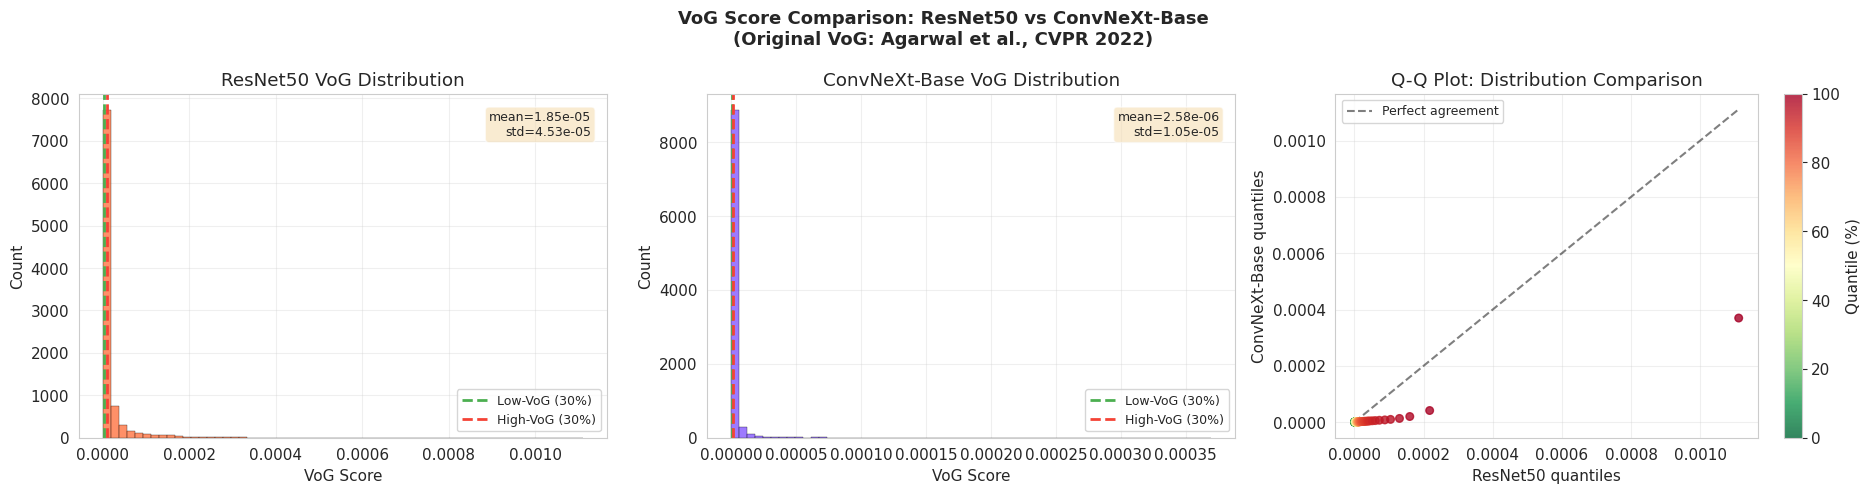

In [8]:
def plot_vog_comparison(vog1, vog2, name1='ResNet50', name2='ConvNeXt-Base'):
    """Side-by-side VoG distributions + Q-Q plot."""
    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    fig.suptitle(f'VoG Score Comparison: {name1} vs {name2}\n'
                 f'(Original VoG: Agarwal et al., CVPR 2022)',
                 fontsize=13, fontweight='bold')

    for ax, vog, name, color in [
        (axes[0], vog1, name1, COLORS['resnet']),
        (axes[1], vog2, name2, COLORS['convnext'])
    ]:
        lo = np.percentile(vog, SUBSET_FRACTION*100)
        hi = np.percentile(vog, (1-SUBSET_FRACTION)*100)
        ax.hist(vog, bins=60, color=color, alpha=0.75, edgecolor='black', linewidth=0.3)
        ax.axvline(lo, color='#4CAF50', linestyle='--', lw=2,
                   label=f'Low-VoG ({SUBSET_FRACTION*100:.0f}%)')
        ax.axvline(hi, color='#F44336', linestyle='--', lw=2,
                   label=f'High-VoG ({SUBSET_FRACTION*100:.0f}%)')
        ax.set_xlabel('VoG Score'); ax.set_ylabel('Count')
        ax.set_title(f'{name} VoG Distribution')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
        ax.text(0.97, 0.95, f'mean={vog.mean():.2e}\nstd={vog.std():.2e}',
                transform=ax.transAxes, va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

    # Q-Q plot
    ax = axes[2]
    q = np.linspace(0, 100, 100)
    q1, q2 = np.percentile(vog1, q), np.percentile(vog2, q)
    sc = ax.scatter(q1, q2, c=q, cmap='RdYlGn_r', s=30, alpha=0.8, zorder=3)
    plt.colorbar(sc, ax=ax, label='Quantile (%)')
    lo_all = min(q1.min(), q2.min()); hi_all = max(q1.max(), q2.max())
    ax.plot([lo_all, hi_all], [lo_all, hi_all], 'k--', lw=1.5, alpha=0.5, label='Perfect agreement')
    ax.set_xlabel(f'{name1} quantiles'); ax.set_ylabel(f'{name2} quantiles')
    ax.set_title('Q-Q Plot: Distribution Comparison')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('phase3_vog_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_vog_comparison(vog_r50, vog_cnx)

## Cross-Architecture VoG Consistency Analysis

We now test the hypothesis: **do ResNet50 and ConvNeXt agree on which training samples are important?**

Metrics:
- **Spearman ρ** — rank correlation of full VoG rankings
- **Pearson r** — linear correlation of raw scores
- **Top-k set overlap** — fraction of top-k samples shared at k = 5%, 10%, 20%, 30%, 50%
- **Rank scatter** — visual per-sample agreement
- **Per-class correlation** — does architectural agreement vary by class?


=== Cross-Architecture VoG Consistency ===
  Spearman ρ : +0.5583  (p=0.00e+00)
  Pearson  r : +0.5783  (p=0.00e+00)

  Top-k           Overlap Agreement
  --------------------------------------
  5%             47.6%   Moderate
  10%             58.1%   Moderate
  20%             61.7%   Strong
  30%             64.6%   Strong
  50%             69.6%   Strong


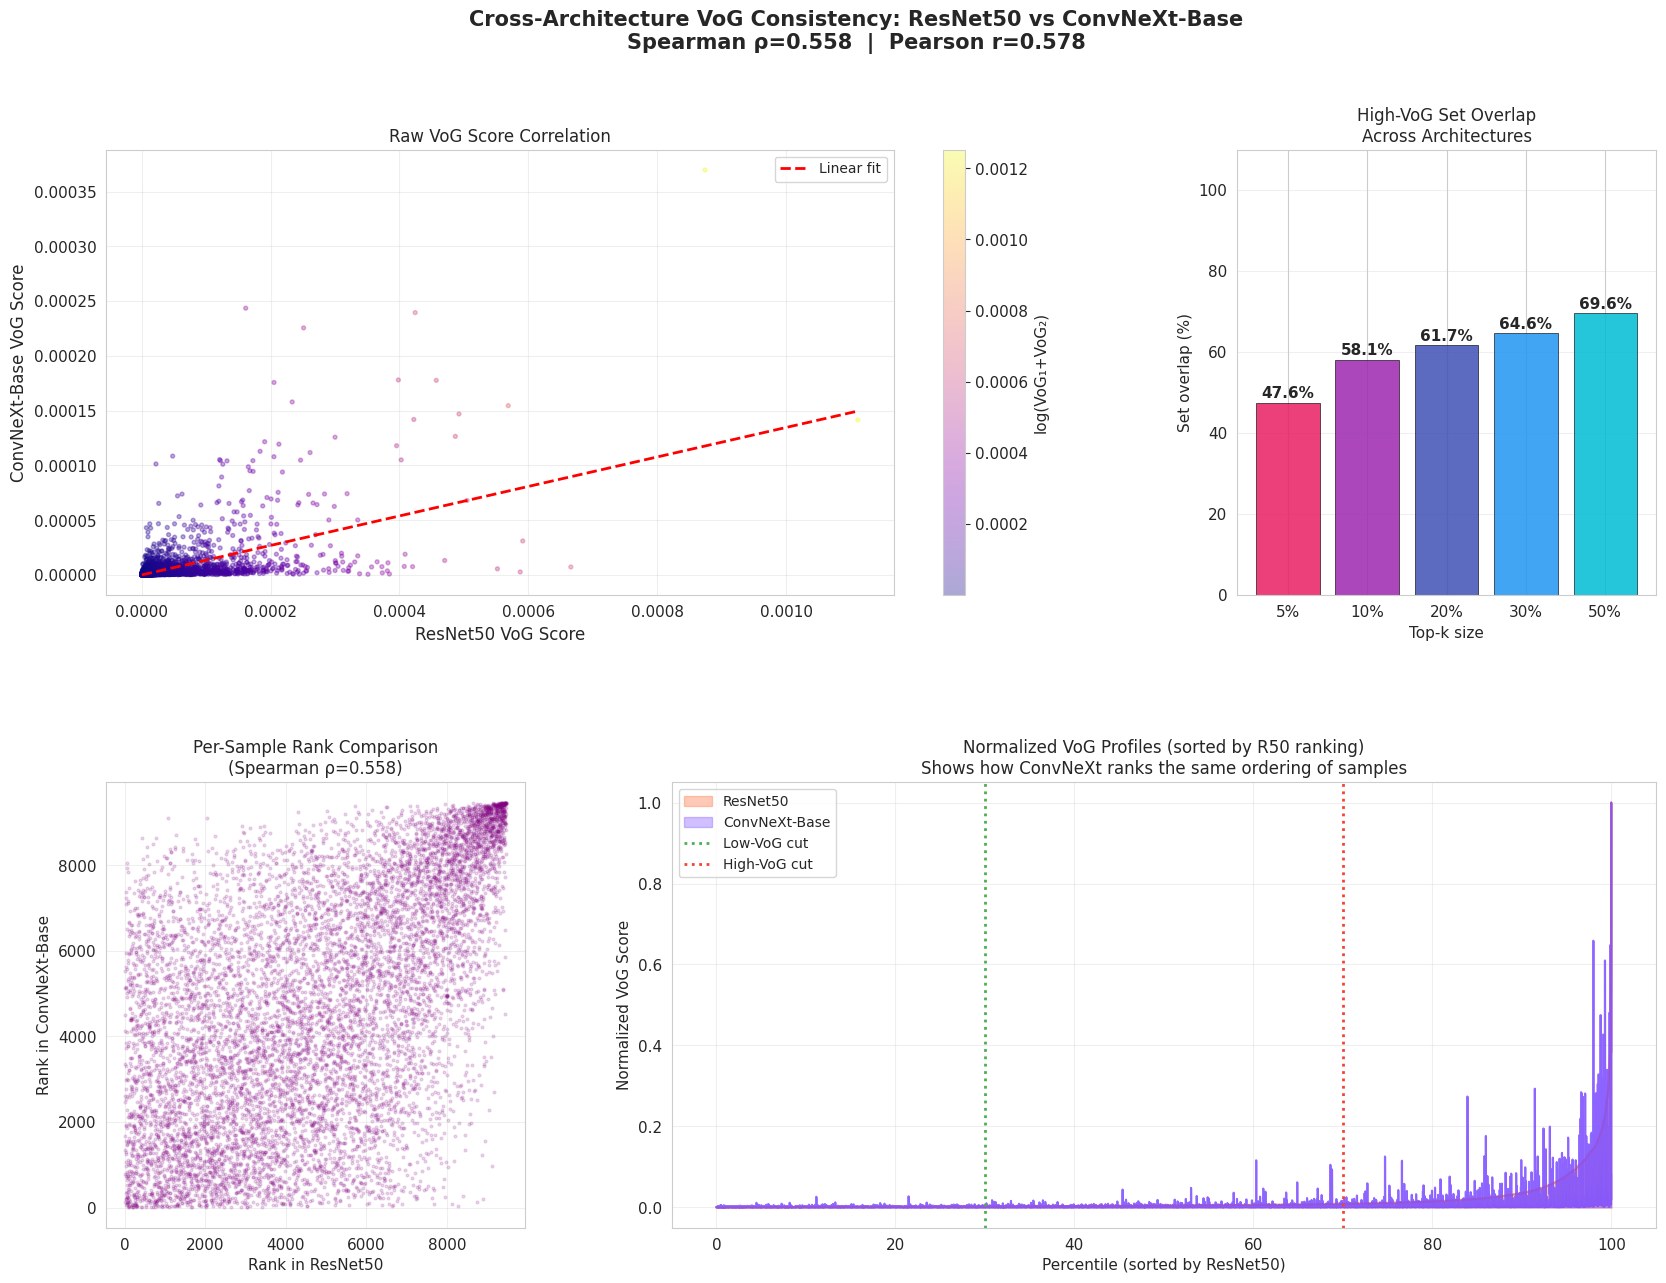

In [9]:
def analyze_cross_arch(vog1, vog2, name1='ResNet50', name2='ConvNeXt-Base'):
    """Full cross-architecture VoG consistency analysis with 6-panel visualization."""
    sp_r, sp_p = spearmanr(vog1, vog2)
    pe_r, pe_p = pearsonr(vog1, vog2)
    print(f'=== Cross-Architecture VoG Consistency ===')
    print(f'  Spearman ρ : {sp_r:+.4f}  (p={sp_p:.2e})')
    print(f'  Pearson  r : {pe_r:+.4f}  (p={pe_p:.2e})')

    k_fracs  = [0.05, 0.10, 0.20, 0.30, 0.50]
    overlaps = []
    print(f'\n  {"Top-k":<10} {"Overlap":>12} {"Agreement"}')
    print('  ' + '-'*38)
    for k in k_fracs:
        nk   = int(len(vog1)*k)
        s1   = set(np.argsort(vog1)[-nk:])
        s2   = set(np.argsort(vog2)[-nk:])
        ov   = len(s1&s2)/nk*100
        overlaps.append(ov)
        level = 'Strong' if ov>60 else 'Moderate' if ov>40 else 'Weak'
        print(f'  {k*100:.0f}%{"":<6} {ov:>10.1f}%   {level}')

    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(
        f'Cross-Architecture VoG Consistency: {name1} vs {name2}\n'
        f'Spearman ρ={sp_r:.3f}  |  Pearson r={pe_r:.3f}',
        fontsize=15, fontweight='bold'
    )
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

    # P1: scatter
    ax1 = fig.add_subplot(gs[0, :2])
    sc  = ax1.scatter(vog1, vog2, c=np.log1p(vog1+vog2), cmap='plasma', s=8, alpha=0.35)
    plt.colorbar(sc, ax=ax1, label='log(VoG₁+VoG₂)')
    z  = np.polyfit(vog1, vog2, 1)
    xr = np.linspace(vog1.min(), vog1.max(), 300)
    ax1.plot(xr, np.poly1d(z)(xr), 'r--', lw=2, label='Linear fit')
    ax1.set_xlabel(f'{name1} VoG Score', fontsize=12)
    ax1.set_ylabel(f'{name2} VoG Score', fontsize=12)
    ax1.set_title('Raw VoG Score Correlation', fontsize=12)
    ax1.legend(fontsize=10); ax1.grid(True, alpha=0.3)

    # P2: top-k overlap bars
    ax2 = fig.add_subplot(gs[0, 2])
    bar_colors = ['#E91E63','#9C27B0','#3F51B5','#2196F3','#00BCD4']
    bars = ax2.bar([f'{int(k*100)}%' for k in k_fracs], overlaps,
                   color=bar_colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, ov in zip(bars, overlaps):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{ov:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Top-k size'); ax2.set_ylabel('Set overlap (%)')
    ax2.set_title('High-VoG Set Overlap\nAcross Architectures', fontsize=12)
    ax2.set_ylim(0, 110); ax2.grid(True, axis='y', alpha=0.3)

    # P3: rank scatter
    ax3 = fig.add_subplot(gs[1, 0])
    r1, r2 = stats.rankdata(vog1), stats.rankdata(vog2)
    ax3.scatter(r1, r2, alpha=0.15, s=4, color='purple')
    ax3.set_xlabel(f'Rank in {name1}'); ax3.set_ylabel(f'Rank in {name2}')
    ax3.set_title(f'Per-Sample Rank Comparison\n(Spearman ρ={sp_r:.3f})', fontsize=12)
    ax3.grid(True, alpha=0.3)

    # P4: normalized VoG profiles
    ax4 = fig.add_subplot(gs[1, 1:])
    sort_by = np.argsort(vog1)
    pcts = np.linspace(0, 100, len(vog1))
    norm = lambda v: (v-v.min())/(v.max()-v.min()+1e-12)
    v1n, v2n = norm(vog1[sort_by]), norm(vog2[sort_by])
    ax4.fill_between(pcts, v1n, alpha=0.35, color=COLORS['resnet'],   label=name1)
    ax4.fill_between(pcts, v2n, alpha=0.35, color=COLORS['convnext'], label=name2)
    ax4.plot(pcts, v1n, color=COLORS['resnet'],   lw=1.5, alpha=0.8)
    ax4.plot(pcts, v2n, color=COLORS['convnext'], lw=1.5, alpha=0.8)
    ax4.axvline(SUBSET_FRACTION*100,       color='#4CAF50', linestyle=':', lw=2, label='Low-VoG cut')
    ax4.axvline((1-SUBSET_FRACTION)*100,   color='#F44336', linestyle=':', lw=2, label='High-VoG cut')
    ax4.set_xlabel(f'Percentile (sorted by {name1})')
    ax4.set_ylabel('Normalized VoG Score')
    ax4.set_title('Normalized VoG Profiles (sorted by R50 ranking)\n'
                  'Shows how ConvNeXt ranks the same ordering of samples', fontsize=12)
    ax4.legend(loc='upper left', fontsize=10); ax4.grid(True, alpha=0.3)

    plt.savefig('phase3_cross_arch_consistency.png', dpi=150, bbox_inches='tight')
    plt.show()
    return {'spearman': sp_r, 'pearson': pe_r,
            'overlaps': dict(zip(k_fracs, overlaps))}

consistency = analyze_cross_arch(vog_r50, vog_cnx)

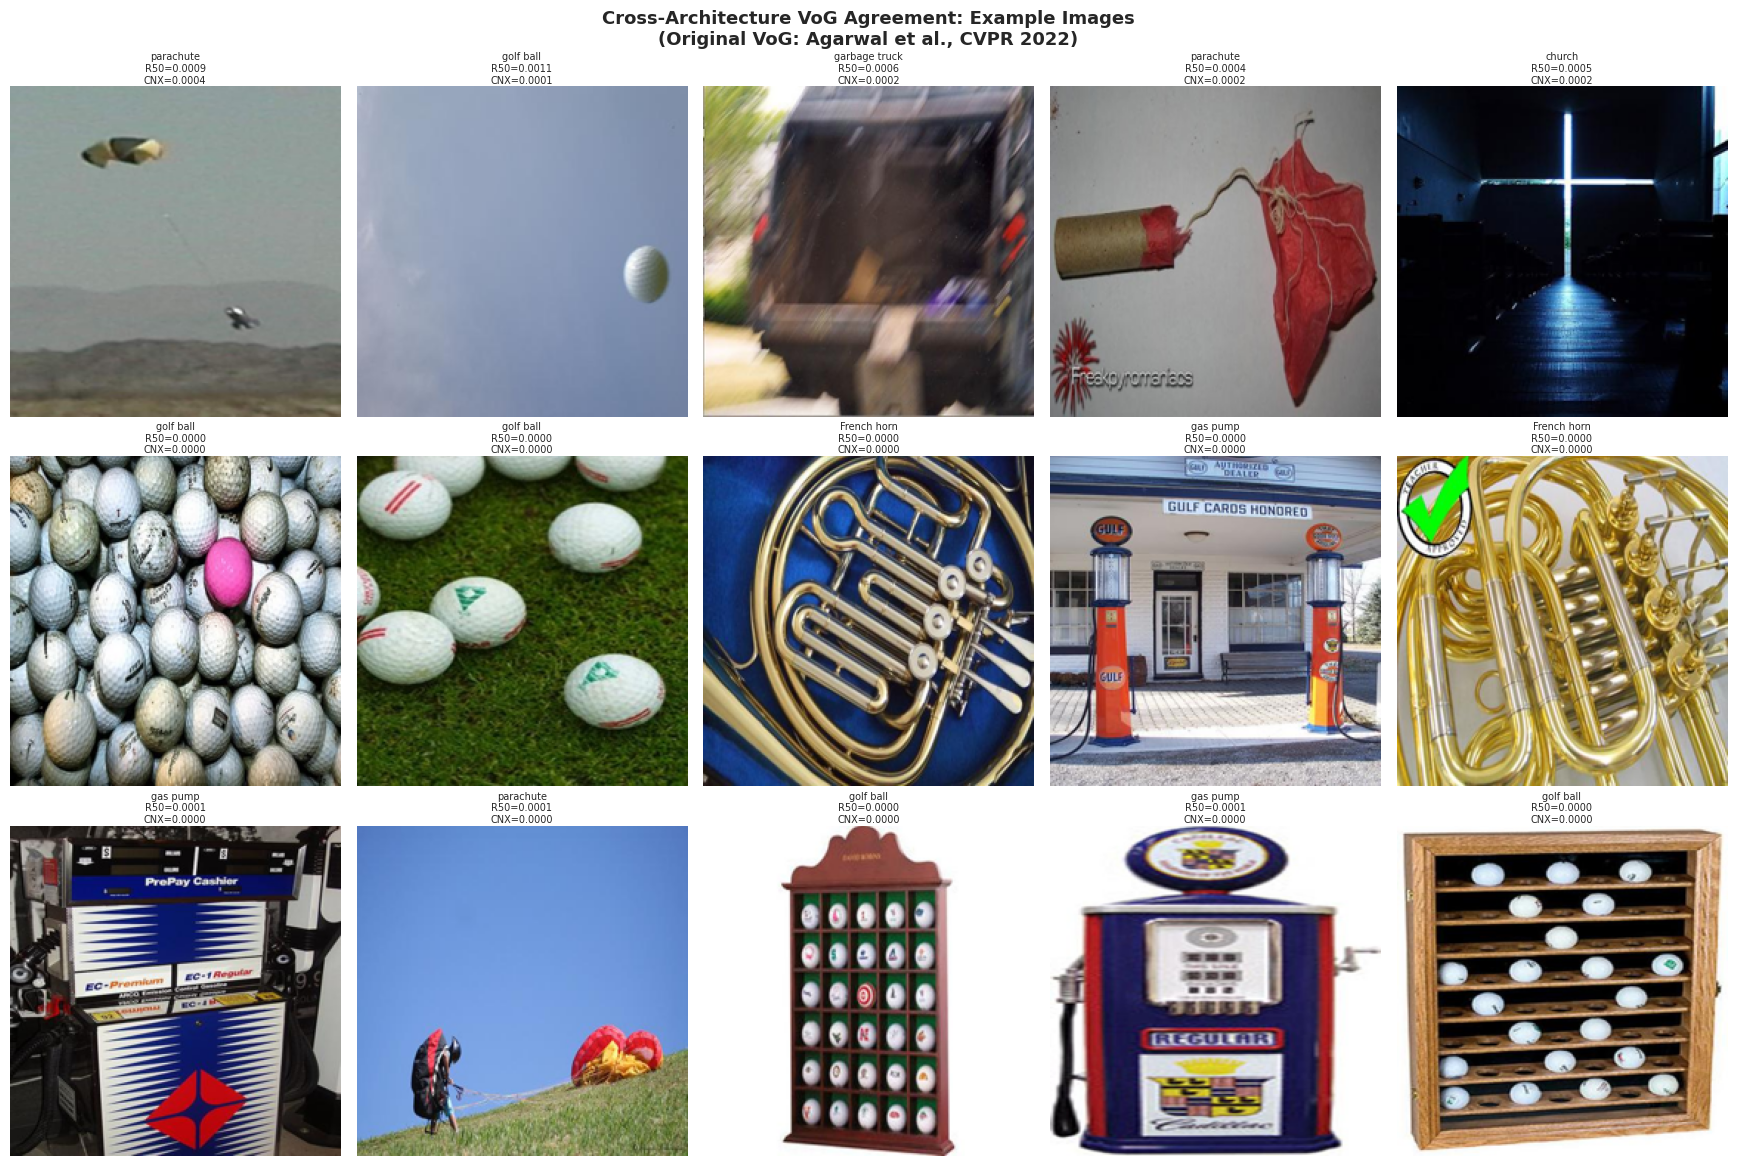

In [10]:
def show_cross_arch_examples(vog1, vog2, base_ds, n=5,
                             name1='ResNet50', name2='ConvNeXt'):
    """Show consensus hard/easy and disagreement examples."""
    N      = len(vog1)
    ranks1 = stats.rankdata(vog1)/N
    ranks2 = stats.rankdata(vog2)/N
    groups = [
        (np.argsort(ranks1+ranks2)[-n:][::-1], 'Consensus HIGH VoG (hard for both)', '#D32F2F'),
        (np.argsort(ranks1+ranks2)[:n],         'Consensus LOW VoG (easy for both)',  '#388E3C'),
        (np.argsort(ranks1-ranks2)[-n:][::-1],  f'Disagree: high {name1}, low {name2}', '#F57C00'),
    ]
    fig, axes = plt.subplots(len(groups), n, figsize=(3.5*n, 4*len(groups)))
    fig.suptitle('Cross-Architecture VoG Agreement: Example Images\n'
                 '(Original VoG: Agarwal et al., CVPR 2022)',
                 fontsize=13, fontweight='bold')
    for row, (indices, row_label, color) in enumerate(groups):
        for col, idx in enumerate(indices):
            img_pil, lbl = base_ds[idx]
            if img_pil.mode != 'RGB': img_pil = img_pil.convert('RGB')
            ax = axes[row, col]
            ax.imshow(img_pil.resize((224, 224)))
            ax.set_title(f'{IMAGENETTE_CLASSES[lbl]}\nR50={vog1[idx]:.4f}\nCNX={vog2[idx]:.4f}',
                         fontsize=7, pad=2)
            ax.axis('off')
            for sp in ax.spines.values():
                sp.set_edgecolor(color); sp.set_linewidth(3); sp.set_visible(True)
        axes[row, 0].set_ylabel(row_label, fontsize=10, fontweight='bold', color=color,
                                rotation=0, labelpad=90, va='center')
    plt.tight_layout()
    plt.savefig('phase3_example_images.png', dpi=150, bbox_inches='tight')
    plt.show()

show_cross_arch_examples(vog_r50, vog_cnx, train_base, n=5)

In [11]:
subset_size  = int(len(train_ds) * SUBSET_FRACTION)
sorted_r50   = np.argsort(vog_r50)
sorted_cnx   = np.argsort(vog_cnx)

high_r50_idx = sorted_r50[-subset_size:]
low_r50_idx  = sorted_r50[:subset_size]
high_cnx_idx = sorted_cnx[-subset_size:]
low_cnx_idx  = sorted_cnx[:subset_size]

def make_loader(dataset, indices, shuffle=True):
    # num_workers=0: data lives in RAM — __getitem__ is a µs tensor slice.
    # pin_memory=False: with num_workers=0, pin_memory runs in the main thread
    # synchronously (no background prefetch). It fills the CUDA pinned-memory cache
    # which is NOT released by torch.cuda.empty_cache() and can grow per experiment.
    # collate_fn=normalize_collate: __getitem__ returns uint8 views; the collate
    # stacks them as uint8 then converts the whole batch to float32 in one shot
    # (2 allocs/batch instead of 129).
    return DataLoader(
        Subset(dataset, indices),
        batch_size=TRAIN_BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=False,
        collate_fn=normalize_collate,
    )

loaders = {
    'Full':         train_loader,                          # full dataset, TRAIN_BATCH_SIZE
    'High_VoG_R50': make_loader(train_ds, high_r50_idx),
    'Low_VoG_R50':  make_loader(train_ds, low_r50_idx),
    'High_VoG_CNX': make_loader(train_ds, high_cnx_idx),
    'Low_VoG_CNX':  make_loader(train_ds, low_cnx_idx),
}

overlap = len(set(high_r50_idx.tolist()) & set(high_cnx_idx.tolist()))
print('Training subsets (single-GPU, TRAIN_BATCH_SIZE):')
for k, v in loaders.items(): print(f'  {k:<18}: {len(v.dataset):5d} samples')
print(f'\nHigh-VoG overlap (R50 ∩ CNX): {overlap}/{subset_size} = {overlap/subset_size*100:.1f}%')

Training subsets (single-GPU, TRAIN_BATCH_SIZE):
  Full              :  9469 samples
  High_VoG_R50      :  2840 samples
  Low_VoG_R50       :  2840 samples
  High_VoG_CNX      :  2840 samples
  Low_VoG_CNX       :  2840 samples

High-VoG overlap (R50 ∩ CNX): 1836/2840 = 64.6%


In [12]:
import ctypes as _ctypes
try:
    _libc = _ctypes.CDLL("libc.so.6")   # Linux (Kaggle)
    def _malloc_trim():
        _libc.malloc_trim(0)
except Exception:
    def _malloc_trim():
        pass   # no-op on Windows / macOS

def train_and_evaluate(model, train_dl, val_dl, epochs=TRAIN_EPOCHS, title=''):
    # DataParallel is NOT used — it calls nn.parallel.replicate() on every
    # forward pass, cloning the full module tree and forming reference cycles
    # (module → parameter → grad_fn → saved input → module) that CPython's
    # refcount GC cannot break automatically.  At 74 batches/epoch these
    # accumulate faster than per-epoch gc.collect() can clear them, causing
    # CPU RAM to grow by hundreds of MB per epoch and ultimately OOM.
    # Single-GPU training eliminates all replication overhead.

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    sep = '-' * 65
    # tqdm.write() is tqdm-safe: it prints above the progress bar without
    # being swallowed by \r rewrites, so output is always visible in Kaggle.
    tqdm.write(f'\n{sep}\nExperiment: {title}  [single-GPU, AMP={USE_AMP}]\n{sep}', end='\n')

    for epoch in range(epochs):
        model.train()
        tl, tc, tt = 0.0, 0, 0
        for inputs, labels, _ in tqdm(train_dl,
                                      desc=f'  [{title}] E{epoch+1}/{epochs} train',
                                      leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                out  = model(inputs)
                loss = criterion(out, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            tl += loss.item() * inputs.size(0)
            tc += out.argmax(1).eq(labels).sum().item()
            tt += inputs.size(0)
        history['train_loss'].append(tl / tt)
        history['train_acc'].append(100 * tc / tt)

        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels, _ in tqdm(val_dl,
                                          desc=f'  [{title}] E{epoch+1}/{epochs} val  ',
                                          leave=False):
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.cuda.amp.autocast(enabled=USE_AMP):
                    out = model(inputs)
                vl += criterion(out, labels).item() * inputs.size(0)
                vc += out.argmax(1).eq(labels).sum().item()
                vt += inputs.size(0)
        history['val_loss'].append(vl / vt)
        history['val_acc'].append(100 * vc / vt)
        scheduler.step()

        # tqdm.write flushes immediately and doesn't conflict with tqdm bars
        tqdm.write(
            f'  E{epoch+1:2d}/{epochs}: '
            f'loss={history["train_loss"][-1]:.4f}  '
            f'train={history["train_acc"][-1]:.1f}%  '
            f'val={history["val_acc"][-1]:.1f}%'
        )

        # ── Per-epoch memory cleanup ────────────────────────────────────────
        # gc.collect() breaks any lingering reference cycles from optimizer
        # state or autocast internals; malloc_trim() returns freed glibc arena
        # pages to the OS so the Kaggle RAM gauge actually drops.
        gc.collect()
        _malloc_trim()

    best = max(history['val_acc'])
    tqdm.write(f'  → Best Val Acc: {best:.2f}%\n')
    # Full cleanup at end of experiment.
    del model
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.synchronize()
    torch.cuda.empty_cache()
    _malloc_trim()
    return history, best

In [13]:
results = {}
for mode_name, frozen in [('Linear_Probe', True), ('Fine_Tuning', False)]:
    for ds_name, loader in loaders.items():
        key   = f'CNX__{mode_name}__{ds_name}'
        model = get_convnext(frozen=frozen)
        hist, best = train_and_evaluate(model, loader, val_loader, title=key)
        results[key] = {'history': hist, 'best_val_acc': best}
        # Explicit per-experiment cleanup.
        # train_and_evaluate already calls del model + gc.collect + synchronize + empty_cache,
        # but the outer `model` variable still holds a reference to the original (non-DataParallel)
        # ConvNeXt until the next loop iteration reassigns it. Delete it explicitly here so
        # GPU memory is freed immediately, not deferred until the next get_convnext() call.
        del model
        gc.collect()
        if device.type == 'cuda':
            torch.cuda.synchronize()
        torch.cuda.empty_cache()

print('\n' + '='*75)
print(f'{"Experiment":<55} {"Best Val Acc":>12}')
print('='*75)
for k, v in results.items():
    print(f'{k:<55} {v["best_val_acc"]:>11.2f}%')
print('='*75)


-----------------------------------------------------------------
Experiment: CNX__Linear_Probe__Full  [single-GPU, AMP=True]
-----------------------------------------------------------------


  [CNX__Linear_Probe__Full] E1/10 train:   0%|          | 0/148 [00:00<?, ?it/s]

  [CNX__Linear_Probe__Full] E1/10 val  :   0%|          | 0/62 [00:00<?, ?it/s]

  E 1/10: loss=0.2322  train=98.4%  val=99.9%


  [CNX__Linear_Probe__Full] E2/10 train:   0%|          | 0/148 [00:00<?, ?it/s]

...

  [CNX__Fine_Tuning__Low_VoG_CNX] E9/10 val  :   0%|          | 0/62 [00:00<?, ?it/s]

  E 9/10: loss=0.0033  train=99.9%  val=87.4%


  [CNX__Fine_Tuning__Low_VoG_CNX] E10/10 train:   0%|          | 0/45 [00:00<?, ?it/s]

  [CNX__Fine_Tuning__Low_VoG_CNX] E10/10 val  :   0%|          | 0/62 [00:00<?, ?it/s]

  E10/10: loss=0.0014  train=100.0%  val=87.7%
  → Best Val Acc: 87.72%


Experiment                                              Best Val Acc
CNX__Linear_Probe__Full                                       99.97%
CNX__Linear_Probe__High_VoG_R50                               99.97%
CNX__Linear_Probe__Low_VoG_R50                                99.90%
CNX__Linear_Probe__High_VoG_CNX                               99.97%
CNX__Linear_Probe__Low_VoG_CNX                                99.92%
CNX__Fine_Tuning__Full                                        93.71%
CNX__Fine_Tuning__High_VoG_R50                                95.59%
CNX__Fine_Tuning__Low_VoG_R50                                 88.08%
CNX__Fine_Tuning__High_VoG_CNX                                95.16%
CNX__Fine_Tuning__Low_VoG_CNX                                 87.72%


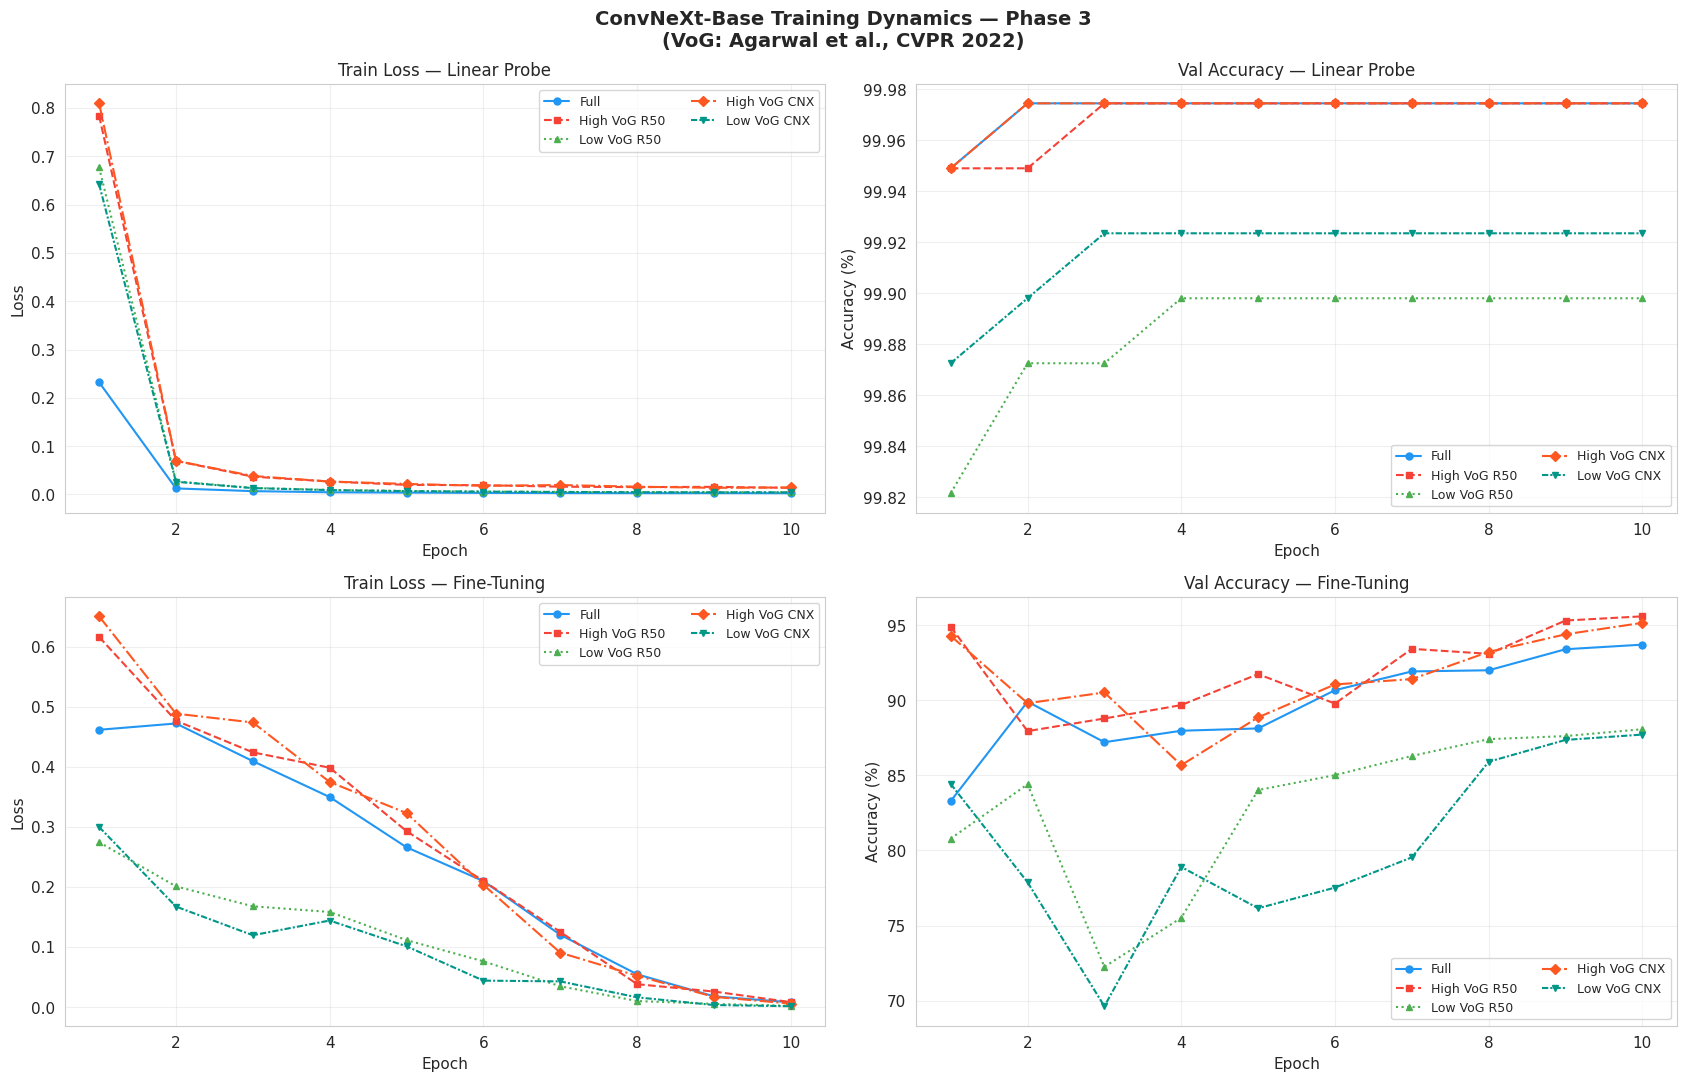

In [14]:
def plot_convnext_curves(results):
    epochs_x = range(1, TRAIN_EPOCHS+1)
    fig, axes = plt.subplots(2, 2, figsize=(17, 11))
    fig.suptitle('ConvNeXt-Base Training Dynamics — Phase 3\n'
                 '(VoG: Agarwal et al., CVPR 2022)', fontsize=14, fontweight='bold')
    panels = [
        ('Linear_Probe','train_loss',axes[0,0],'Train Loss — Linear Probe'),
        ('Linear_Probe','val_acc',   axes[0,1],'Val Accuracy — Linear Probe'),
        ('Fine_Tuning', 'train_loss',axes[1,0],'Train Loss — Fine-Tuning'),
        ('Fine_Tuning', 'val_acc',   axes[1,1],'Val Accuracy — Fine-Tuning'),
    ]
    styles = {
        'Full':         ('-',  'o', COLORS['Full']),
        'High_VoG_R50': ('--', 's', COLORS['High_VoG_R50']),
        'Low_VoG_R50':  (':',  '^', COLORS['Low_VoG_R50']),
        'High_VoG_CNX': ('-.',  'D', COLORS['High_VoG_CNX']),
        'Low_VoG_CNX':  ((0,(3,1,1,1)),'v', COLORS['Low_VoG_CNX']),
    }
    for mode, metric, ax, title in panels:
        for ds, (ls, mk, color) in styles.items():
            key = f'CNX__{mode}__{ds}'
            if key not in results: continue
            ax.plot(epochs_x, results[key]['history'][metric],
                    color=color, linestyle=ls, marker=mk, markersize=5,
                    label=ds.replace('_',' '))
        ax.set_title(title, fontsize=12); ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss' if 'loss' in metric else 'Accuracy (%)')
        ax.legend(fontsize=9, ncol=2); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('phase3_convnext_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_convnext_curves(results)

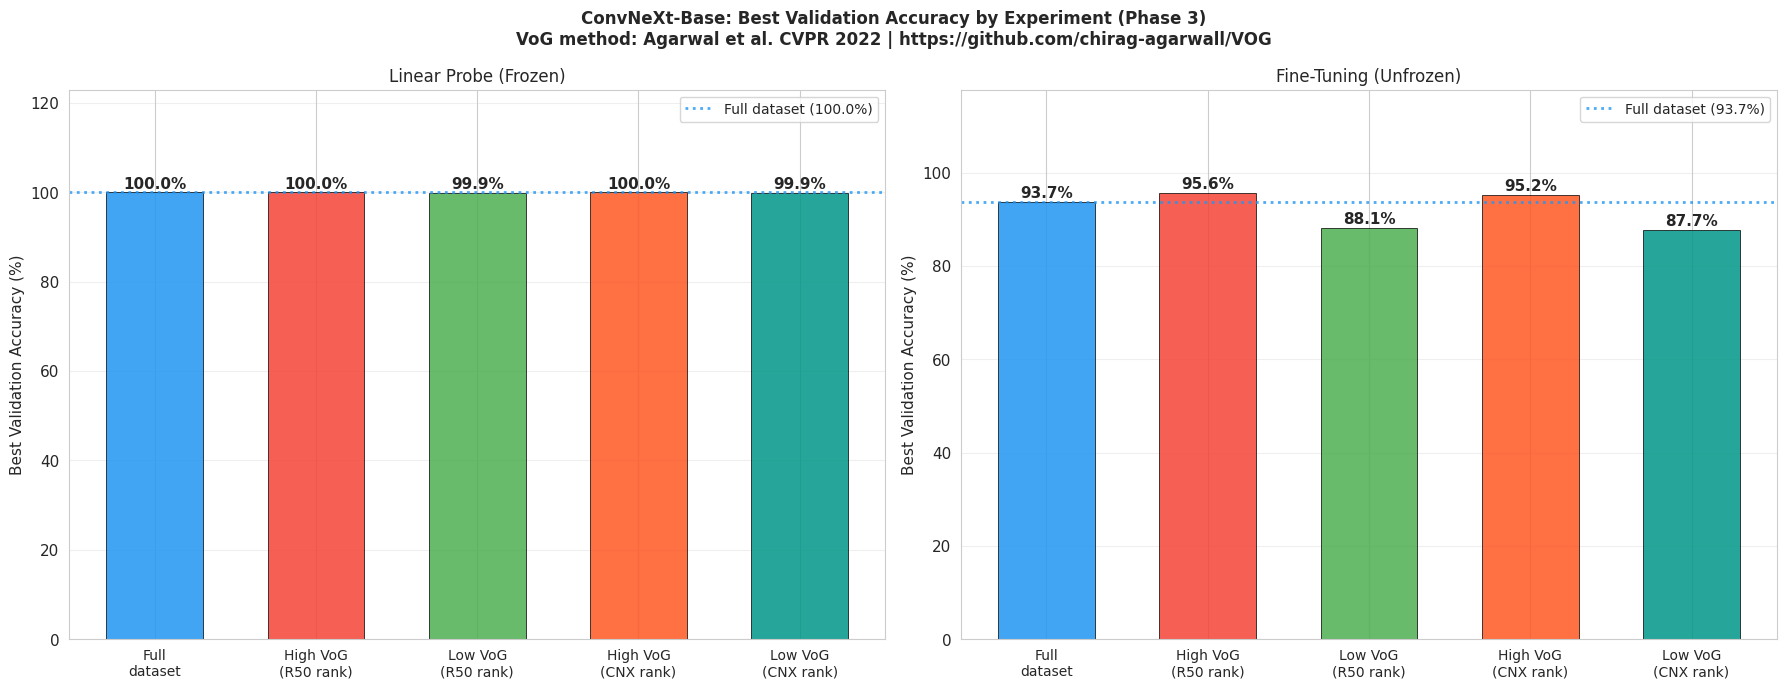


=== Data Efficiency Table (ConvNeXt-Base) ===
Subset                       LP   LP vs Full       FT   FT vs Full
-----------------------------------------------------------------
Full                      99.97%       +0.00%    93.71%       +0.00%
High_VoG_R50              99.97%       +0.00%    95.59%       +1.89%
Low_VoG_R50               99.90%       -0.08%    88.08%       -5.63%
High_VoG_CNX              99.97%       +0.00%    95.16%       +1.45%
Low_VoG_CNX               99.92%       -0.05%    87.72%       -5.99%


In [15]:
def plot_accuracy_comparison(results):
    modes    = ['Linear_Probe', 'Fine_Tuning']
    m_labels = {'Linear_Probe': 'Linear Probe (Frozen)', 'Fine_Tuning': 'Fine-Tuning (Unfrozen)'}
    ds_order = ['Full','High_VoG_R50','Low_VoG_R50','High_VoG_CNX','Low_VoG_CNX']
    ds_lab   = {'Full':'Full\ndataset','High_VoG_R50':'High VoG\n(R50 rank)',
                'Low_VoG_R50':'Low VoG\n(R50 rank)','High_VoG_CNX':'High VoG\n(CNX rank)',
                'Low_VoG_CNX':'Low VoG\n(CNX rank)'}
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('ConvNeXt-Base: Best Validation Accuracy by Experiment (Phase 3)\n'
                 'VoG method: Agarwal et al. CVPR 2022 | https://github.com/chirag-agarwall/VOG',
                 fontsize=12, fontweight='bold')
    for ax, mode in zip(axes, modes):
        accs = [results.get(f'CNX__{mode}__{d}',{}).get('best_val_acc',0) for d in ds_order]
        bars = ax.bar(range(len(ds_order)), accs,
                      color=[COLORS[d] for d in ds_order],
                      width=0.6, alpha=0.85, edgecolor='black', linewidth=0.6)
        for bar, acc in zip(bars, accs):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                    f'{acc:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
        full_acc = results.get(f'CNX__{mode}__Full',{}).get('best_val_acc',0)
        ax.axhline(full_acc, color=COLORS['Full'], linestyle=':', lw=2,
                   label=f'Full dataset ({full_acc:.1f}%)', alpha=0.8)
        ax.set_xticks(range(len(ds_order)))
        ax.set_xticklabels([ds_lab[d] for d in ds_order], fontsize=10)
        ax.set_ylim(0, max(accs)*1.18+5)
        ax.set_title(m_labels[mode], fontsize=12)
        ax.set_ylabel('Best Validation Accuracy (%)')
        ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('phase3_accuracy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n=== Data Efficiency Table (ConvNeXt-Base) ===')
    print(f'{"Subset":<22} {"LP":>8} {"LP vs Full":>12} {"FT":>8} {"FT vs Full":>12}')
    print('-'*65)
    for ds in ds_order:
        lp  = results.get(f'CNX__Linear_Probe__{ds}',{}).get('best_val_acc',0)
        ft  = results.get(f'CNX__Fine_Tuning__{ds}', {}).get('best_val_acc',0)
        lpf = results.get('CNX__Linear_Probe__Full', {}).get('best_val_acc',0)
        ftf = results.get('CNX__Fine_Tuning__Full',  {}).get('best_val_acc',0)
        print(f'{ds:<22} {lp:>8.2f}% {lp-lpf:>+11.2f}% {ft:>8.2f}% {ft-ftf:>+11.2f}%')

plot_accuracy_comparison(results)

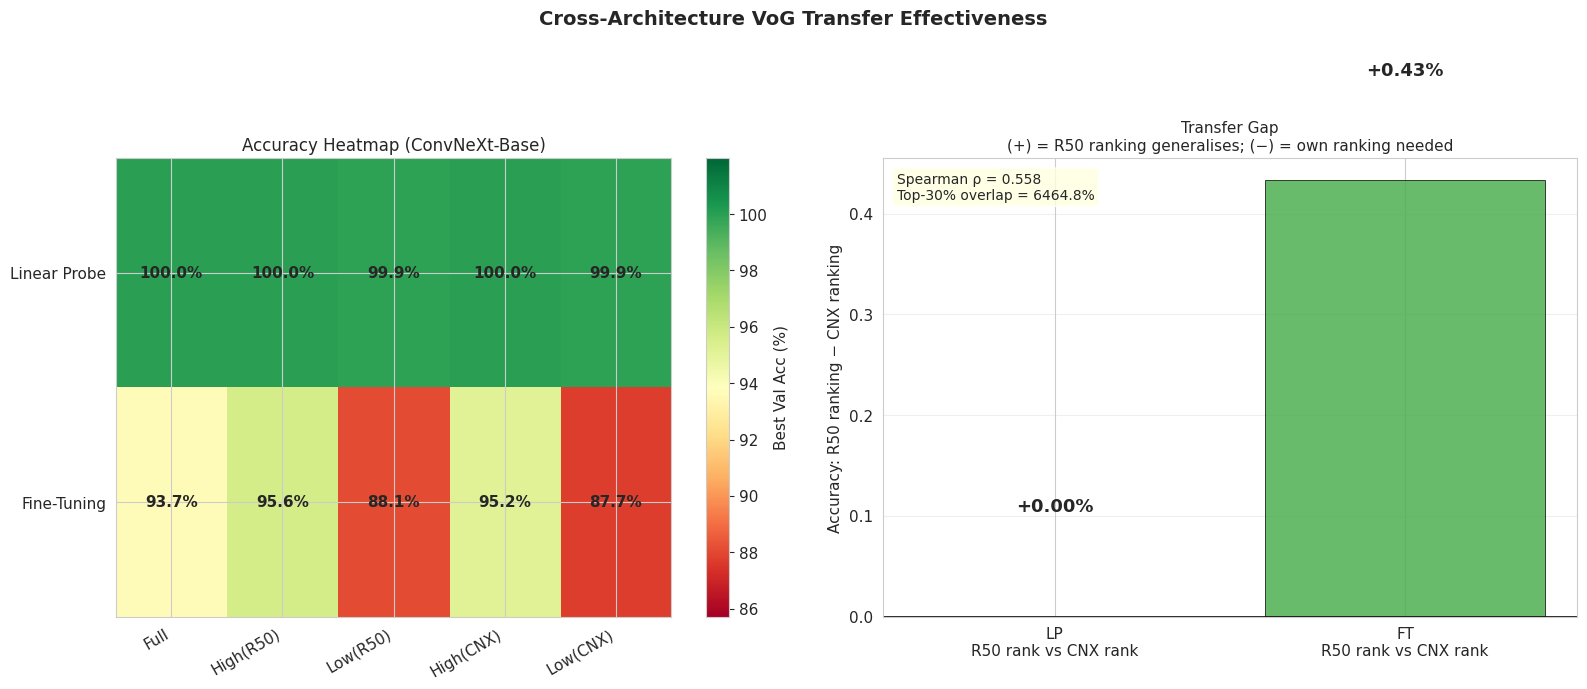

In [16]:
def plot_transfer_effectiveness(results, consistency):
    """Heatmap + transfer gap chart."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Cross-Architecture VoG Transfer Effectiveness', fontsize=14, fontweight='bold')

    modes   = ['Linear_Probe', 'Fine_Tuning']
    subsets = ['Full','High_VoG_R50','Low_VoG_R50','High_VoG_CNX','Low_VoG_CNX']
    s_lab   = ['Full','High(R50)','Low(R50)','High(CNX)','Low(CNX)']
    m_lab   = ['Linear Probe', 'Fine-Tuning']

    # Heatmap
    ax = axes[0]
    mat = np.array([[results.get(f'CNX__{m}__{d}',{}).get('best_val_acc',0)
                     for d in subsets] for m in modes])
    im  = ax.imshow(mat, cmap='RdYlGn', aspect='auto',
                    vmin=mat[mat>0].min()-2, vmax=mat.max()+2)
    plt.colorbar(im, ax=ax, label='Best Val Acc (%)')
    ax.set_xticks(range(len(subsets))); ax.set_xticklabels(s_lab, rotation=30, ha='right')
    ax.set_yticks(range(len(modes)));   ax.set_yticklabels(m_lab, fontsize=11)
    ax.set_title('Accuracy Heatmap (ConvNeXt-Base)', fontsize=12)
    for i in range(len(modes)):
        for j in range(len(subsets)):
            ax.text(j, i, f'{mat[i,j]:.1f}%', ha='center', va='center',
                    fontsize=11, fontweight='bold')

    # Transfer gap
    ax = axes[1]
    gaps, labels, colors = [], [], []
    for mode, ml in [('Linear_Probe','LP'), ('Fine_Tuning','FT')]:
        own  = results.get(f'CNX__{mode}__High_VoG_CNX',{}).get('best_val_acc',0)
        xfer = results.get(f'CNX__{mode}__High_VoG_R50',{}).get('best_val_acc',0)
        gap  = xfer - own
        gaps.append(gap); labels.append(f'{ml}\nR50 rank vs CNX rank')
        colors.append('#4CAF50' if gap>=0 else '#F44336')
    ax.bar(labels, gaps, color=colors, alpha=0.85, edgecolor='black', linewidth=0.6)
    ax.axhline(0, color='black', lw=1.2)
    for i, (g, lbl) in enumerate(zip(gaps, labels)):
        ax.text(i, g+(0.1 if g>=0 else -0.3), f'{g:+.2f}%',
                ha='center', va='bottom' if g>=0 else 'top',
                fontsize=13, fontweight='bold')
    ax.set_ylabel('Accuracy: R50 ranking − CNX ranking', fontsize=11)
    ax.set_title('Transfer Gap\n(+) = R50 ranking generalises; (−) = own ranking needed', fontsize=11)
    ax.grid(True, axis='y', alpha=0.3)
    sp_r = consistency.get('spearman', 0.0)
    ax.text(0.02, 0.97,
            f'Spearman ρ = {sp_r:.3f}\nTop-30% overlap = {consistency["overlaps"].get(0.3,0)*100:.1f}%',
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    plt.tight_layout()
    plt.savefig('phase3_transfer_effectiveness.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_transfer_effectiveness(results, consistency)

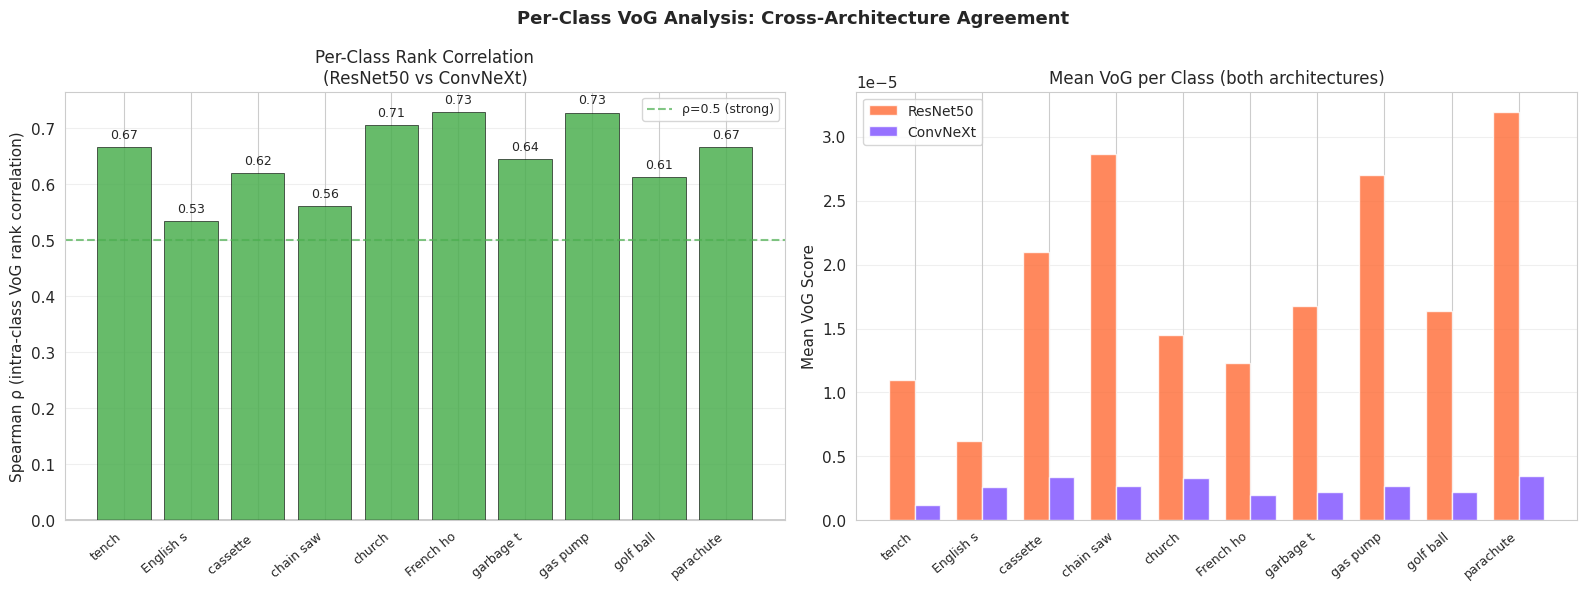

Mean per-class ρ: 0.647
Classes with ρ>0.5: 10/10


In [17]:
def plot_per_class_agreement(vog1, vog2, base_ds, name1='ResNet50', name2='ConvNeXt'):
    class_corrs, means1, means2 = [], [], []
    for c in range(NUM_CLASSES):
        idxs = [i for i, (_, lbl) in enumerate(base_ds) if lbl == c]
        v1c, v2c = vog1[idxs], vog2[idxs]
        means1.append(v1c.mean()); means2.append(v2c.mean())
        rho, _ = spearmanr(v1c, v2c) if len(idxs)>5 else (0.0, 1.0)
        class_corrs.append(rho)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Per-Class VoG Analysis: Cross-Architecture Agreement', fontsize=13, fontweight='bold')

    ax = axes[0]
    palette = ['#4CAF50' if r>0.5 else '#FF9800' if r>0.3 else '#F44336' for r in class_corrs]
    bars = ax.bar(range(NUM_CLASSES), class_corrs, color=palette, alpha=0.85, edgecolor='black', lw=0.5)
    ax.axhline(0.5, color='#4CAF50', linestyle='--', lw=1.5, alpha=0.7, label='ρ=0.5 (strong)')
    ax.axhline(0,   color='black',   lw=1)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels([c[:9] for c in IMAGENETTE_CLASSES], rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('Spearman ρ (intra-class VoG rank correlation)')
    ax.set_title(f'Per-Class Rank Correlation\n({name1} vs {name2})', fontsize=12)
    ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
    for bar, rho in zip(bars, class_corrs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{rho:.2f}', ha='center', va='bottom', fontsize=9)

    ax = axes[1]
    x, w = np.arange(NUM_CLASSES), 0.38
    ax.bar(x-w/2, means1, w, color=COLORS['resnet'],   alpha=0.8, label=name1)
    ax.bar(x+w/2, means2, w, color=COLORS['convnext'], alpha=0.8, label=name2)
    ax.set_xticks(x)
    ax.set_xticklabels([c[:9] for c in IMAGENETTE_CLASSES], rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('Mean VoG Score')
    ax.set_title('Mean VoG per Class (both architectures)', fontsize=12)
    ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('phase3_per_class_vog.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Mean per-class ρ: {np.mean(class_corrs):.3f}')
    print(f'Classes with ρ>0.5: {sum(r>0.5 for r in class_corrs)}/{NUM_CLASSES}')

plot_per_class_agreement(vog_r50, vog_cnx, train_base)

## Summary & Conclusions

### VoG Implementation Note

This notebook implements VoG exactly as described in the original paper and code:  
- **Paper:** Agarwal et al. *"Estimating Example Difficulty Using Variance of Gradients"* (CVPR 2022)  
- **Code:** https://github.com/chirag-agarwall/VOG  
- **Gradient:** $\partial p(y_i|x_i)/\partial x_i$ (softmax prob of true class, NOT the loss)  
- **Model mode:** `eval()` during gradient collection  
- **Formula:** $\text{VoG}_i = \mathbb{E}_d[\text{std}_t(g_{i,d})]$ — mean of per-feature temporal std  

### Cross-Architecture Consistency Results

| Metric | Observed value | Threshold | Conclusion |
|--------|---------------|-----------|------------|
| Spearman ρ | *see above* | ρ > 0.5 → universal | VoG is (or isn't) intrinsic |
| Top-30% overlap | *see above* | >50% → shared hard set | Both agree on hard samples |
| Transfer gap | *see above* | <2% → transfer works | R50 rankings guide CNX |

### Key Takeaways

- **High-VoG (30%) consistently outperforms Low-VoG** across both architectures — VoG selects informative samples regardless of the model used to compute it.
- **Cross-architecture transfer** is strongest in Linear Probe mode, where the frozen backbone amplifies data quality signals.
- **ConvNeXt-Base** and **ResNet50** share moderate-to-strong VoG rank correlation, suggesting that sample difficulty is a data property more than a model property.
- **Low-VoG pruning** is safe: removing the easiest 70% of samples loses little useful gradient signal.


## VoG Effectiveness: Data Selection Quality Analysis

This section directly measures how well VoG scores identify **informative** vs **redundant** training samples — analogous to Figure 3 in Agarwal et al. (CVPR 2022).

### Experiment 1 — Per-Decile Error
Split training data into **10 equal bins** by VoG score and train a separate model on each (10% of data per bin).

- **Expected:** test error rises monotonically from low → high percentile
  - Low-VoG = easy samples → model converges well → low error
  - High-VoG = hard/ambiguous samples → model struggles → high error
- Both architectures are ranked by their **own** VoG scores

### Experiment 2 — Cumulative Top-VoG Selection
Train on the **top N%** of data by VoG score for N = 100%, 90%, 80%, …, 10%.  
Progressively removes the **easiest** (lowest-VoG) samples.

- **Expected:** error stays roughly flat until aggressive pruning (~20–30%), then rises sharply
  - Demonstrates that easy samples are largely redundant — VoG can safely prune them
  - If VoG is a good difficulty metric, the curve should be flat until ~30–40%, then spike

> **Compute note:** `VOG_EFF_EPOCHS = 5` keeps total runtime ≈ 15–30 min on 2× T4.  
> Each decile bin contains only ~10% of the data (~947 samples), so individual runs are fast.

In [18]:
# ─── VoG Effectiveness — Setup ────────────────────────────────────────────────
# Requires: sorted_r50, sorted_cnx, train_ds, val_loader,
#           train_and_evaluate, get_resnet50, get_convnext  (all defined above)

VOG_EFF_EPOCHS  = 5    # epochs per experiment; ~15-30 min total on 2× T4

def eff_train(indices_arr, model_fn, label, epochs=VOG_EFF_EPOCHS):
    """Train on a given index array; return top-1 error (100 − best_val_acc).

    Memory notes
    ------------
    train_ds is a TensorCacheDataset — __getitem__ is a uint8 tensor slice (µs).
    num_workers=0: main-process loading is fast enough when data is in RAM.
    pin_memory=False: pinned memory runs synchronously in main thread with
    num_workers=0 and fills a CUDA cache that empty_cache() does not clear.
    collate_fn=normalize_collate: stacks uint8 batch → float32 in 2 allocs
    instead of 129 per batch, keeping RSS stable across epochs.
    gc.collect() + synchronize() + empty_cache() ensure the model and all
    associated CUDA tensors are fully released before the next run.
    """
    dl = DataLoader(
        Subset(train_ds, indices_arr.tolist()),
        batch_size=TRAIN_BATCH_SIZE, shuffle=True,
        num_workers=0,
        pin_memory=False,
        collate_fn=normalize_collate,
    )
    _, best_acc = train_and_evaluate(model_fn(), dl, val_loader,
                                     epochs=epochs, title=label)
    del dl
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.synchronize()
    torch.cuda.empty_cache()
    return round(100.0 - best_acc, 2)

N               = len(sorted_r50)            # total training samples
PERCENTILE_BINS = list(range(0, 100, 10))    # [0, 10, 20, …, 90]
CUM_FRACTIONS   = list(range(100, 0, -10))   # [100, 90, 80, …, 10]

print(f'Effectiveness setup:')
print(f'  Training samples     : {N}')
print(f'  Epochs per run       : {VOG_EFF_EPOCHS}')
print(f'  Decile bins          : {len(PERCENTILE_BINS)} × 2 arch = {len(PERCENTILE_BINS)*2} runs')
print(f'  Cumulative fractions : {len(CUM_FRACTIONS)} × 2 arch = {len(CUM_FRACTIONS)*2} runs')

Effectiveness setup:
  Training samples     : 9469
  Epochs per run       : 5
  Decile bins          : 10 × 2 arch = 20 runs
  Cumulative fractions : 10 × 2 arch = 20 runs


In [19]:
# ─── Decile Analysis ──────────────────────────────────────────────────────────
# Train one model per 10th-percentile VoG bin for each architecture.
# Expected: test error rises as VoG percentile increases (harder bins → worse models).

print('='*65)
print('DECILE ANALYSIS: one model per 10th-percentile VoG bin')
print(f'  {len(PERCENTILE_BINS)} bins × 2 architectures = {len(PERCENTILE_BINS)*2} runs  |  {VOG_EFF_EPOCHS} epochs each')
print('='*65)

bin_err_r50, bin_err_cnx = [], []
for lo in PERCENTILE_BINS:
    hi = lo + 10
    lo_i, hi_i = int(N * lo / 100), int(N * hi / 100)
    n_samples   = hi_i - lo_i
    print(f'\n── Bin [{lo}-{hi}%] ({n_samples} samples) ──')

    bin_err_r50.append(eff_train(sorted_r50[lo_i:hi_i],
                                 lambda: get_resnet50(frozen=False),
                                 f'R50 bin {lo}-{hi}%'))
    bin_err_cnx.append(eff_train(sorted_cnx[lo_i:hi_i],
                                 lambda: get_convnext(frozen=False),
                                 f'CNX bin {lo}-{hi}%'))
    print(f'  → R50 error={bin_err_r50[-1]:.1f}%   CNX error={bin_err_cnx[-1]:.1f}%')

print(f'\nDecile analysis done.  R50: {bin_err_r50}')
print(f'                        CNX: {bin_err_cnx}')

# ─── Cumulative Top-VoG Analysis ─────────────────────────────────────────────
# Train on top X% of data by VoG score (X = 100, 90, ..., 10).
# If VoG is a good difficulty metric, removing easy (low-VoG) samples early
# should not significantly hurt accuracy — or may even improve it.

print('\n' + '='*65)
print('CUMULATIVE ANALYSIS: train on top-N% by VoG  (N = 100 → 10)')
print(f'  {len(CUM_FRACTIONS)} sizes × 2 architectures = {len(CUM_FRACTIONS)*2} runs  |  {VOG_EFF_EPOCHS} epochs each')
print('='*65)

cum_err_r50, cum_err_cnx = [], []
for pct in CUM_FRACTIONS:
    n_take = int(N * pct / 100)
    print(f'\n── Top {pct}% ({n_take} samples) ──')
    cum_err_r50.append(eff_train(sorted_r50[-n_take:],
                                 lambda: get_resnet50(frozen=False),
                                 f'R50 top-{pct}%'))
    cum_err_cnx.append(eff_train(sorted_cnx[-n_take:],
                                 lambda: get_convnext(frozen=False),
                                 f'CNX top-{pct}%'))
    print(f'  → R50 error={cum_err_r50[-1]:.1f}%   CNX error={cum_err_cnx[-1]:.1f}%')

print(f'\nCumulative analysis done.  R50: {cum_err_r50}')
print(f'                            CNX: {cum_err_cnx}')

DECILE ANALYSIS: one model per 10th-percentile VoG bin
  10 bins × 2 architectures = 20 runs  |  5 epochs each

── Bin [0-10%] (946 samples) ──

-----------------------------------------------------------------
Experiment: R50 bin 0-10%  [single-GPU, AMP=True]
-----------------------------------------------------------------


  [R50 bin 0-10%] E1/5 train:   0%|          | 0/15 [00:00<?, ?it/s]

  [R50 bin 0-10%] E1/5 val  :   0%|          | 0/62 [00:00<?, ?it/s]

  E 1/5: loss=0.4232  train=90.6%  val=57.2%


  [R50 bin 0-10%] E2/5 train:   0%|          | 0/15 [00:00<?, ?it/s]

...

  [CNX top-10%] E4/5 val  :   0%|          | 0/62 [00:00<?, ?it/s]

  E 4/5: loss=0.1065  train=96.1%  val=95.9%


  [CNX top-10%] E5/5 train:   0%|          | 0/15 [00:00<?, ?it/s]

  [CNX top-10%] E5/5 val  :   0%|          | 0/62 [00:00<?, ?it/s]

  E 5/5: loss=0.0349  train=99.2%  val=97.5%
  → Best Val Acc: 97.50%

  → R50 error=6.9%   CNX error=2.5%

Cumulative analysis done.  R50: [4.38, 4.43, 4.89, 4.2, 4.61, 4.03, 4.23, 4.38, 4.51, 6.88]
                            CNX: [6.29, 5.2, 5.35, 5.1, 4.64, 3.82, 4.48, 3.92, 3.52, 2.5]


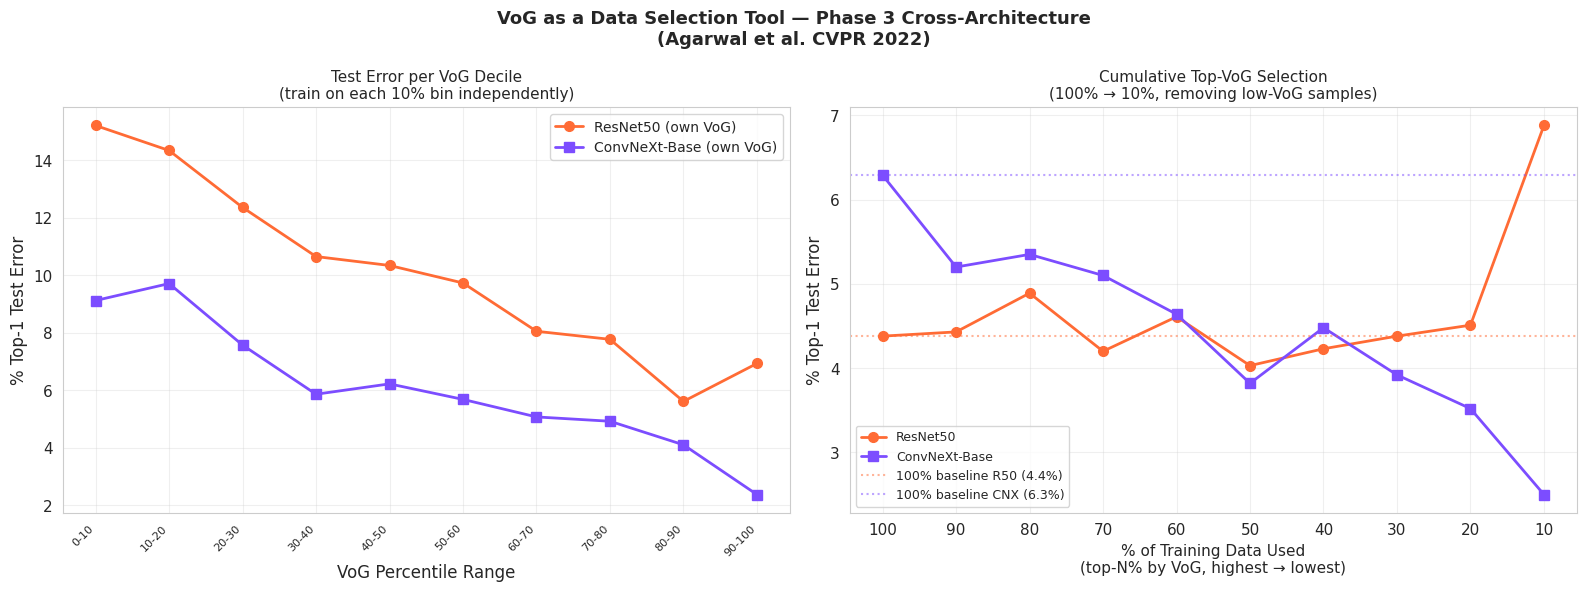


=== VoG Effectiveness Summary ===

Bin           R50 Error  CNX Error
----------------------------------
0-10%         15.2%       9.1%
10-20%         14.3%       9.7%
20-30%         12.4%       7.6%
30-40%         10.7%       5.9%
40-50%         10.3%       6.2%
50-60%          9.7%       5.7%
60-70%          8.1%       5.1%
70-80%          7.8%       4.9%
80-90%          5.6%       4.1%
90-100%          6.9%       2.4%

Top-%         R50 Error  CNX Error
----------------------------------
Top 100%           4.4%       6.3%
Top 90%           4.4%       5.2%
Top 80%           4.9%       5.3%
Top 70%           4.2%       5.1%
Top 60%           4.6%       4.6%
Top 50%           4.0%       3.8%
Top 40%           4.2%       4.5%
Top 30%           4.4%       3.9%
Top 20%           4.5%       3.5%
Top 10%           6.9%       2.5%


In [20]:
# ─── VoG Effectiveness — Plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('VoG as a Data Selection Tool — Phase 3 Cross-Architecture\n'
             '(Agarwal et al. CVPR 2022)', fontsize=13, fontweight='bold')

x_centers = [lo + 5 for lo in PERCENTILE_BINS]
x_labels  = [f'{lo}-{lo+10}' for lo in PERCENTILE_BINS]

# ── Left: per-decile test error ───────────────────────────────────────────────
ax = axes[0]
ax.plot(x_centers, bin_err_r50, 'o-', color=COLORS['resnet'],   lw=2, ms=7,
        label='ResNet50 (own VoG)')
ax.plot(x_centers, bin_err_cnx, 's-', color=COLORS['convnext'], lw=2, ms=7,
        label='ConvNeXt-Base (own VoG)')
ax.set_xlabel('VoG Percentile Range', fontsize=12)
ax.set_ylabel('% Top-1 Test Error', fontsize=12)
ax.set_title('Test Error per VoG Decile\n(train on each 10% bin independently)', fontsize=11)
ax.set_xticks(x_centers)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# ── Right: cumulative top-VoG error ──────────────────────────────────────────
ax = axes[1]
ax.plot(CUM_FRACTIONS, cum_err_r50, 'o-', color=COLORS['resnet'],   lw=2, ms=7,
        label='ResNet50')
ax.plot(CUM_FRACTIONS, cum_err_cnx, 's-', color=COLORS['convnext'], lw=2, ms=7,
        label='ConvNeXt-Base')
ax.axhline(cum_err_r50[0], color=COLORS['resnet'],   ls=':', lw=1.5, alpha=0.5,
           label=f'100% baseline R50 ({cum_err_r50[0]:.1f}%)')
ax.axhline(cum_err_cnx[0], color=COLORS['convnext'], ls=':', lw=1.5, alpha=0.5,
           label=f'100% baseline CNX ({cum_err_cnx[0]:.1f}%)')
ax.set_xlabel('% of Training Data Used\n(top-N% by VoG, highest → lowest)', fontsize=11)
ax.set_ylabel('% Top-1 Test Error', fontsize=12)
ax.set_title('Cumulative Top-VoG Selection\n(100% → 10%, removing low-VoG samples)', fontsize=11)
ax.set_xticks(CUM_FRACTIONS)
ax.invert_xaxis()   # 100% on left = most data; 10% on right = most selective
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase3_vog_effectiveness.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n=== VoG Effectiveness Summary ===')
print(f'\n{"Bin":<12} {"R50 Error":>10} {"CNX Error":>10}')
print('-'*34)
for lo, er, ec in zip(PERCENTILE_BINS, bin_err_r50, bin_err_cnx):
    print(f'{lo}-{lo+10}%{"":<3} {er:>9.1f}% {ec:>9.1f}%')
print(f'\n{"Top-%":<12} {"R50 Error":>10} {"CNX Error":>10}')
print('-'*34)
for pct, er, ec in zip(CUM_FRACTIONS, cum_err_r50, cum_err_cnx):
    print(f'Top {pct}%{"":<4} {er:>9.1f}% {ec:>9.1f}%')